### Surface

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 62, longitude: 1440, latitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 496B 2019-01-01 ... 2019-01-31T12:00:00
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    pm1        (time, latitude, longitude) float32 257MB ...
    pm2p5      (time, latitude, longitude) float32 257MB ...
    pm10       (time, latitude, longitude) float32 257MB ...
    u10        (time, latitude, longitude) float64 515MB ...
    v10        (time, latitude, longitude) float64 515MB ...
    t2m        (time, latitude, longitude) float64 515MB ...
    msl        (time, latitude, longitude) float64 515MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat May 31 17:49:33 2025: cdo merge /media/akhtarmunir/Extr...
    CDO:          Climate 

/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


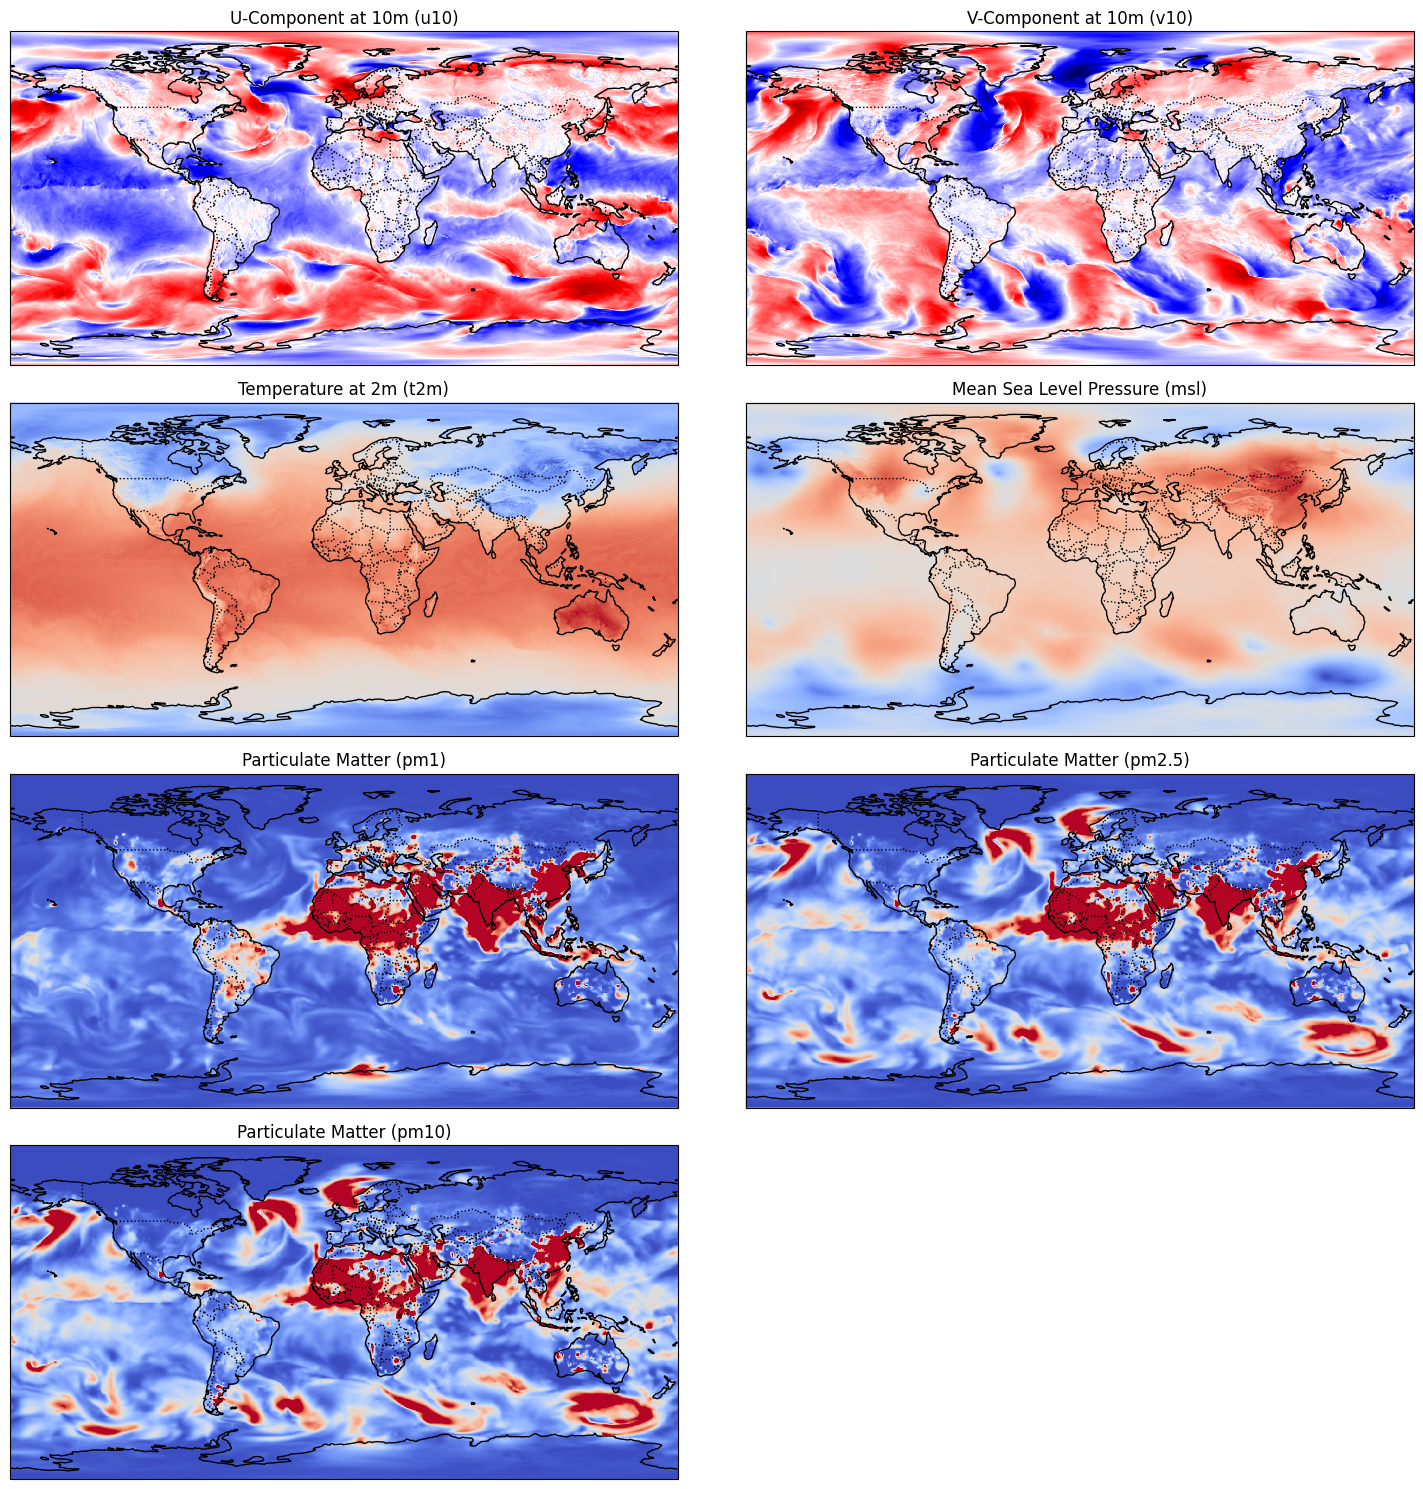

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
ds = xr.open_dataset('/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_201901.nc')
print(ds)

# Extract the first time point
first_time = ds.isel(time=0)

# Set up the plotting figure with a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the variables and their titles, along with color maps
variables = ['u10', 'v10', 't2m', 'msl', 'pm1', 'pm2p5', 'pm10']
titles = ['U-Component at 10m (u10)', 'V-Component at 10m (v10)', 'Temperature at 2m (t2m)', 'Mean Sea Level Pressure (msl)', 'Particulate Matter (pm1)', 'Particulate Matter (pm2.5)', 'Particulate Matter (pm10)']
colormaps = ['seismic', 'seismic', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm']
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Loop over the variables and plot each one
for i, var in enumerate(variables):
    ax = axs[i // 2, i % 2]
    data = first_time[var]

    if var in pm_vars:
        # Compute the 5th and 95th percentiles
        vmin = float(data.quantile(0))
        vmax = float(data.quantile(0.95))
        im = data.plot(ax=ax, cmap=colormaps[i], vmin=vmin, vmax=vmax, add_colorbar=False)
    else:
        im = data.plot(ax=ax, cmap=colormaps[i], add_colorbar=False)

    ax.coastlines(resolution='110m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='black')
    ax.set_title(titles[i])

# Remove the last empty subplot
fig.delaxes(axs[3, 1])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [8]:
pm_vars = ['pm1', 'pm2p5', 'pm10']

for var in pm_vars:
    print(f"Attributes for {var}:")
    print(ds[var].attrs)
    print()

Attributes for pm1:
{'standard_name': 'mass_concentration_of_pm1_ambient_aerosol_particles_in_air', 'long_name': 'Particulate matter d <= 1 um', 'units': 'kg m**-3'}

Attributes for pm2p5:
{'standard_name': 'mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air', 'long_name': 'Particulate matter d <= 2.5 um', 'units': 'kg m**-3'}

Attributes for pm10:
{'standard_name': 'mass_concentration_of_pm10_ambient_aerosol_particles_in_air', 'long_name': 'Particulate matter d <= 10 um', 'units': 'kg m**-3'}



In [6]:
print(ds["pm2p5"].values.min())
print(ds["pm1"].values.min())
print(ds["pm10"].values.min())

0.0
0.0
0.0


<xarray.Dataset> Size: 172MB
Dimensions:    (longitude: 480, latitude: 241, time: 62)
Coordinates:
  * longitude  (longitude) float32 2kB 0.0 0.75 1.5 2.25 ... 357.8 358.5 359.2
  * latitude   (latitude) float32 964B 90.0 89.25 88.5 ... -88.5 -89.25 -90.0
  * time       (time) datetime64[ns] 496B 2019-01-01 ... 2019-01-31T12:00:00
Data variables:
    pm1        (time, latitude, longitude) float64 57MB ...
    pm2p5      (time, latitude, longitude) float64 57MB ...
    pm10       (time, latitude, longitude) float64 57MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2025-05-31 07:23:33 GMT by grib_to_netcdf-2.41.0: grib_to_n...


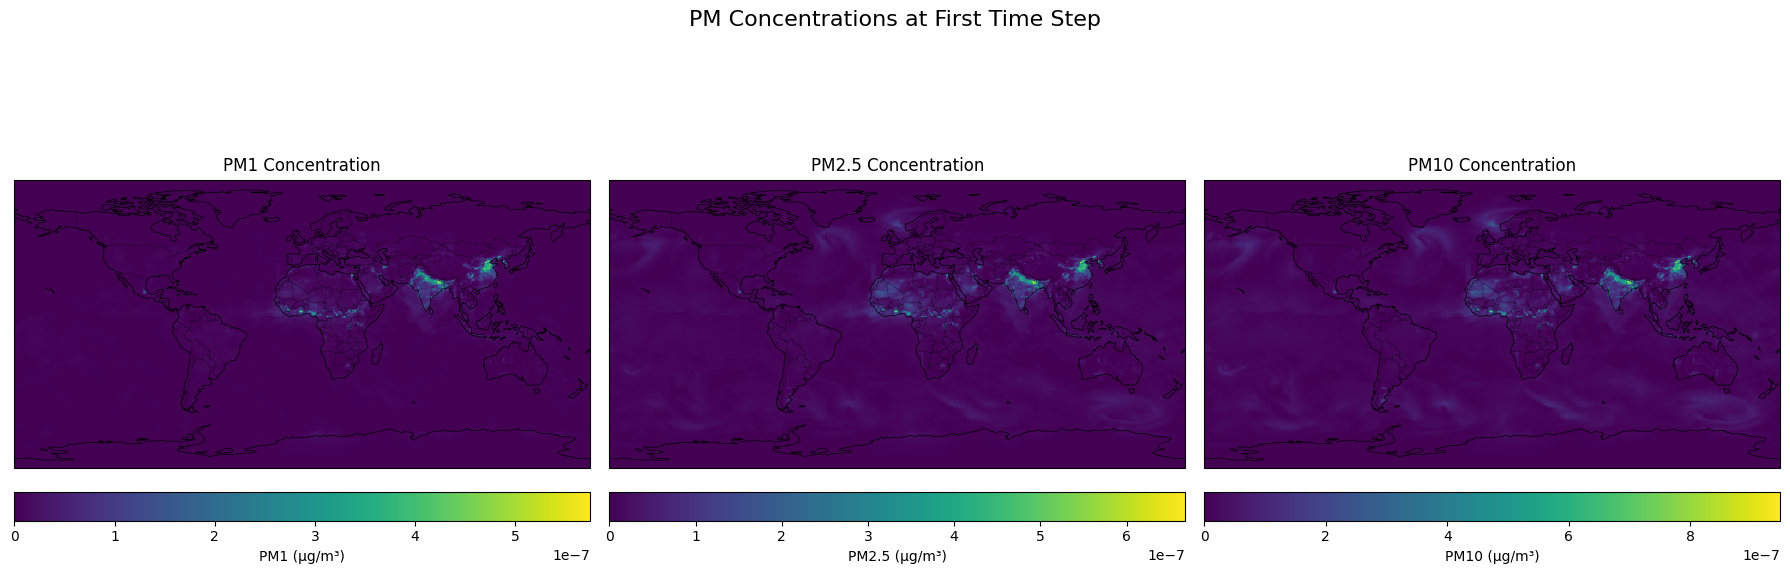

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Path to your .nc file
file_path = "/l/users/fahad.khan/akhtar/Pangu/data/data_prep/pm-orig/cams_201901.nc"
ds = xr.open_dataset(file_path)
print(ds)

# Map dataset variable names to display labels
pm_vars = {
    "pm1": "PM1",
    "pm2p5": "PM2.5",
    "pm10": "PM10"
}

# Set up figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, var_key in zip(axes, pm_vars):
    # Extract data for first time step
    data = ds[var_key].isel(time=0)
    
    # Plot the heatmap
    heatmap = ax.pcolormesh(
        data.longitude, data.latitude, data,
        transform=ccrs.PlateCarree(),
        shading="auto", cmap="viridis"
    )

    # Add geographical features
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='black')

    # Set title and colorbar
    ax.set_title(f"{pm_vars[var_key]} Concentration", fontsize=12)
    cbar = plt.colorbar(heatmap, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label(f"{pm_vars[var_key]} (µg/m³)")  # Adjust label units as needed

# Global figure title
plt.suptitle("PM Concentrations at First Time Step", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show plot
plt.show()

In [4]:
print(ds["pm2p5"].values.min())
print(ds["pm1"].values.min())
print(ds["pm10"].values.min())

0.0
0.0
0.0


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 62, longitude: 1440, latitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 496B 2019-01-01 ... 2019-01-31T12:00:00
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    pm1        (time, latitude, longitude) float32 257MB ...
    pm2p5      (time, latitude, longitude) float32 257MB ...
    pm10       (time, latitude, longitude) float32 257MB ...
    u10        (time, latitude, longitude) float64 515MB ...
    v10        (time, latitude, longitude) float64 515MB ...
    t2m        (time, latitude, longitude) float64 515MB ...
    msl        (time, latitude, longitude) float64 515MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat May 31 17:49:33 2025: cdo merge /media/akhtarmunir/Extr...
    CDO:          Climate 

/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


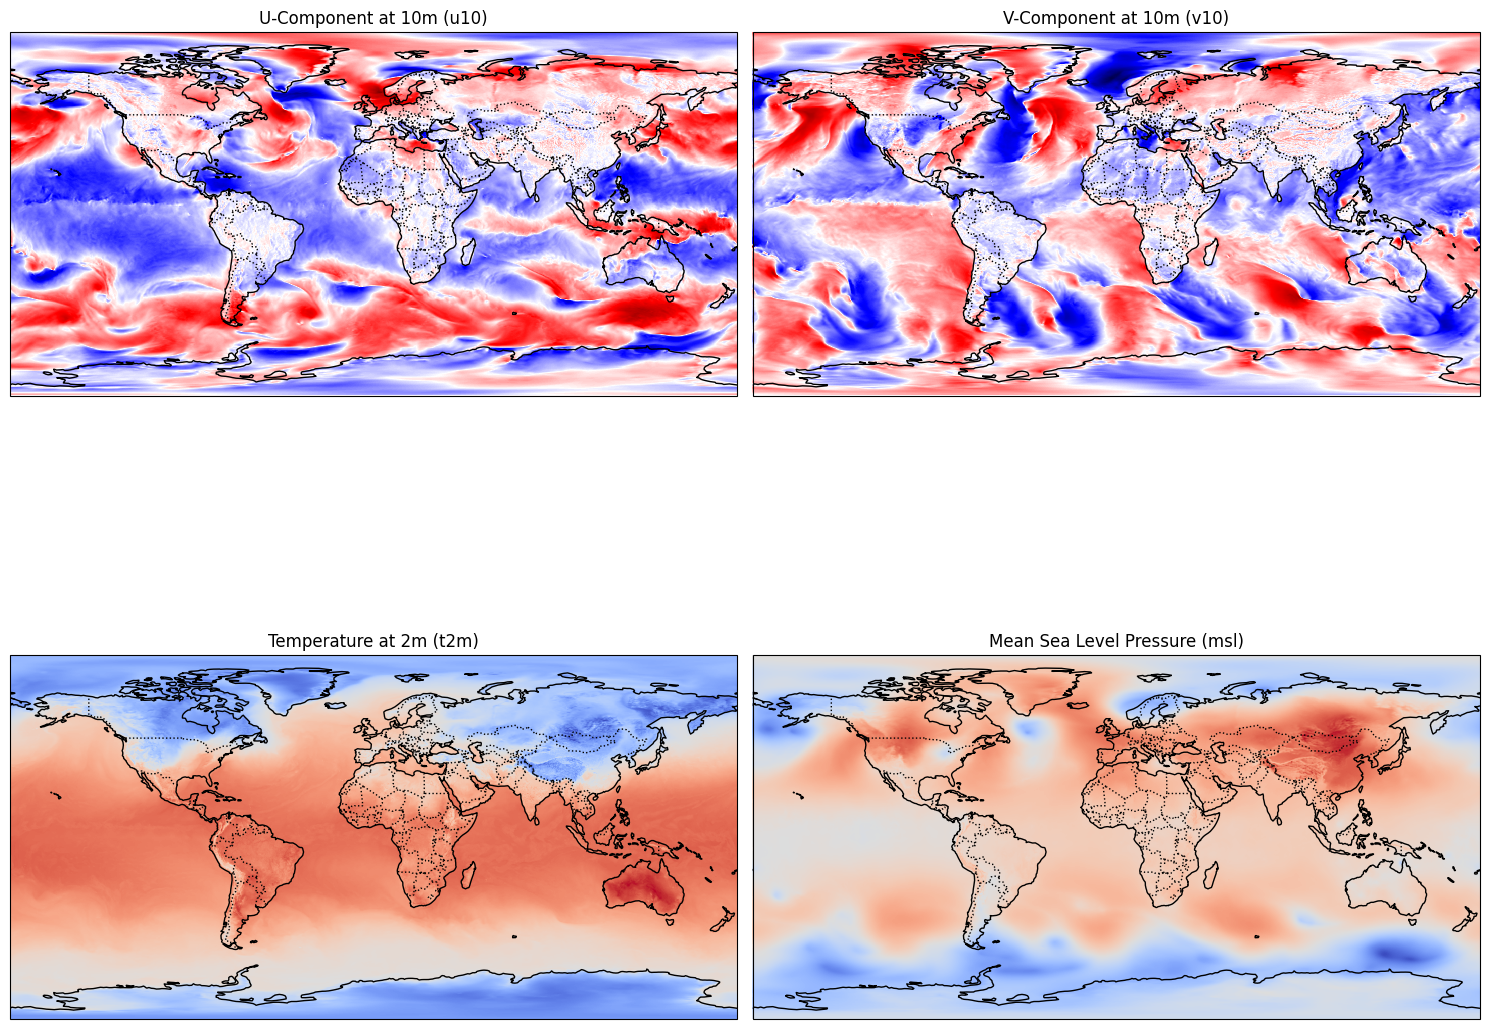

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
ds = xr.open_dataset('/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_201901.nc')
print(ds)

# Extract the first time point
first_time = ds.isel(time=0)

# Set up the plotting figure with a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the variables and their titles, along with color maps
variables = ['u10', 'v10', 't2m', 'msl']
titles = ['U-Component at 10m (u10)', 'V-Component at 10m (v10)', 'Temperature at 2m (t2m)', 'Mean Sea Level Pressure (msl)']
colormaps = ['seismic', 'seismic', 'coolwarm', 'coolwarm']

# Loop over the variables and plot each one
for i, var in enumerate(variables):
    ax = axs[i // 2, i % 2]  # Adjust subplot position
    data = first_time[var]  # No need to slice level, as this is surface data
    
    # Plot the data with the specified colormap
    im = data.plot(ax=ax, cmap=colormaps[i], add_colorbar=False)

    # Add continent lines and labels
    ax.coastlines(resolution='110m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='black')
    ax.set_title(titles[i])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()